# 问题二：目标差分直接拟合 + 最佳 lag

本 notebook 从 `p2_diff_hurdle.ipynb` 复制而来，并移除 Hurdle 逻辑：

```text
1. 对 FILT. NTU 做一阶差分，并截断到 [-1, 1]
2. 不进行小差分映射，不训练零/非零分类器
3. 每个输入变量只保留训练集上相关性最高的 lag
4. 随机划分 80% train / 20% test
5. 使用 LightGBM、Random Forest、MLP 直接拟合带符号差分
6. 测试时以前一时刻真实 FILT. NTU 加预测差分，重建当前原始值
7. 使用重建原始值计算 MAE、RMSE 和 R²
```

输出目录：

```text
outputs/problem2_diff_direct_bestlag_random80/
```

## 1. 导入依赖库

LightGBM 如果本地环境没有安装会给出明确错误。

In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception as e:
    LGBM_AVAILABLE = False
    LGBM_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

print("LightGBM available:", LGBM_AVAILABLE)
if not LGBM_AVAILABLE:
    print("LightGBM import error:", LGBM_IMPORT_ERROR)

LightGBM available: True


## 2. 参数设置

这里保持流程清晰，不做复杂超参数搜索。


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_diff_direct_bestlag_random80"

RANDOM_STATE = 42
TEST_SIZE = 0.20
RECORD_INTERVAL_HOURS = 2

DIFF_CLIP_LOWER = -1.0
DIFF_CLIP_UPPER = 1.0

CORE_FEATURES = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

EXOG_LEVEL_LAGS = list(range(0, 7))
TARGET_DIFF_HISTORY_LAGS = [1, 2, 3]
CLIP_PREDICTIONS = True

print("参数设置完成。")

参数设置完成。


## 3. 自动定位 `merged.xlsx`

从原始 `merged.xlsx` 读取，不依赖任何中间文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： /Users/jinyu/workspace/2026亚太杯/codes/p2
使用数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
输出目录： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 缺失值处理

处理原则：

```text
1. 只保留第二问目标变量和核心输入变量；
2. 所有变量转为 numeric；
3. F/RIDE 缺失值填 0，R/W PH 缺失值填 7，ALUM 缺失值填 0.06；
4. 除上述三个变量外，其余变量按时间顺序进行线性插值；
5. 插值后仍缺失的值再 forward fill / backward fill；
6. 后续模型 pipeline 内仍保留 SimpleImputer(strategy='median')，防止 lag 特征产生的少量缺失影响训练。
```

输出：

```text
problem2_diff_clip1_missing_audit.xlsx
```


In [5]:
available_features = [c for c in CORE_FEATURES if c in df.columns]
missing_features = [c for c in CORE_FEATURES if c not in df.columns]

print("可用核心输入变量：", available_features)
print("缺失核心输入变量：", missing_features)

use_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_features
use_cols = list(dict.fromkeys(use_cols))

data = df[use_cols].copy().sort_values("DATETIME").reset_index(drop=True)

# 转 numeric
for col in [TARGET_COL] + available_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_before = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_before": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_before": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

# 指定变量使用固定值填充
fixed_fill_values = {
    "F/RIDE": 0,
    "R/W PH": 7,
    "ALUM": 0.06,
}
for col, fill_value in fixed_fill_values.items():
    if col in data.columns:
        data[col] = data[col].fillna(fill_value)

# 其他变量线性插值 + 前后填充
for col in [TARGET_COL] + available_features:
    if col in fixed_fill_values:
        continue

    data[col] = (
        data[col]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

missing_after = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_after": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_after": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

missing_audit = missing_before.merge(missing_after, on="column", how="left")

missing_audit_path = OUTPUT_DIR / "problem2_diff_clip1_missing_audit.xlsx"
missing_audit.to_excel(missing_audit_path, index=False)

print("缺失值处理审计表已保存：", missing_audit_path)
display(missing_audit)

print("处理后数据规模：", data.shape)
display(data.head())


可用核心输入变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心输入变量： []
缺失值处理审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_clip1_missing_audit.xlsx


,column,missing_count_before,missing_rate_before,missing_count_after,missing_rate_after
0,FILT. NTU,0,0.000000,0,0.0
1,R/W NTU,0,0.000000,0,0.0
2,R/W PH,1644,0.301099,0,0.0
3,ALUM,1644,0.301099,0,0.0
4,F/RIDE,0,0.000000,0,0.0
5,R/W FLOW,0,0.000000,0,0.0


处理后数据规模： (5460, 8)


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5


## 6. 差分处理：当前值 - 前一个时间节点值

对目标变量和核心输入变量都做一阶差分：

```text
DIFF_X_t = X_t - X_{t-1}
```

输出：

```text
problem2_diff_raw_data.xlsx
```


In [6]:
def safe_name(col):
    return (
        str(col)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


diff_data = data.copy()

target_diff_col = f"DIFF_{safe_name(TARGET_COL)}"
previous_target_col = f"PREVIOUS_{safe_name(TARGET_COL)}"
diff_data[previous_target_col] = diff_data[TARGET_COL].shift(1)
diff_data[target_diff_col] = diff_data[TARGET_COL] - diff_data[previous_target_col]

diff_raw_path = OUTPUT_DIR / "problem2_diff_raw_data.xlsx"
diff_data[["DATETIME", "OP_DATE", previous_target_col, TARGET_COL] + available_features + [target_diff_col]].to_excel(diff_raw_path, index=False)

print("原始差分数据已保存：", diff_raw_path)
print("目标差分列：", target_diff_col)
display(diff_data[["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_diff_col] + available_features].head(12))


原始差分数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_raw_data.xlsx
目标差分列： DIFF_FILT_NTU


,DATETIME,OP_DATE,PREVIOUS_FILT_NTU,FILT. NTU,DIFF_FILT_NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,NaN,0.04,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.04,0.05,0.01,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.00,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.00,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.00,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.05,0.06,0.01,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,0.06,0.05,-0.01,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.05,0.05,0.00,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.05,0.05,0.00,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.05,0.05,0.00,67,7.0,0.04,0.0,48.6


## 7. 将目标差分截断到 ±1

仅进行：

```python
np.clip(diff_value, -1, 1)
```

不再将小差分映射为 0。

In [7]:
clip_data = diff_data.copy()

target_clip_col = f"{target_diff_col}_CLIP1"
clip_data[target_clip_col] = clip_data[target_diff_col].clip(
    lower=DIFF_CLIP_LOWER,
    upper=DIFF_CLIP_UPPER,
)

valid_raw = clip_data[target_diff_col].dropna()
valid_clip = clip_data[target_clip_col].dropna()

clip_audit_df = pd.DataFrame([{
    "original_variable": TARGET_COL,
    "diff_column": target_diff_col,
    "clip_column": target_clip_col,
    "raw_diff_min": valid_raw.min() if len(valid_raw) else np.nan,
    "raw_diff_max": valid_raw.max() if len(valid_raw) else np.nan,
    "clip_min": valid_clip.min() if len(valid_clip) else np.nan,
    "clip_max": valid_clip.max() if len(valid_clip) else np.nan,
    "count_above_1_before_clip": int((valid_raw > DIFF_CLIP_UPPER).sum()),
    "count_below_minus1_before_clip": int((valid_raw < DIFF_CLIP_LOWER).sum()),
}])

clip_audit_path = OUTPUT_DIR / "problem2_diff_clip1_audit.xlsx"
clip_data_path = OUTPUT_DIR / "problem2_diff_clip1_data.xlsx"

clip_audit_df.to_excel(clip_audit_path, index=False)
clip_data[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_diff_col, target_clip_col]
    + available_features
].to_excel(clip_data_path, index=False)

print("差分截断审计表已保存：", clip_audit_path)
print("差分数据已保存：", clip_data_path)
display(clip_audit_df)
display(
    clip_data[
        ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_diff_col, target_clip_col]
        + available_features
    ].head(30)
)

差分截断审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_clip1_audit.xlsx
差分数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_clip1_data.xlsx


,original_variable,diff_column,clip_column,raw_diff_min,raw_diff_max,clip_min,clip_max,count_above_1_before_clip,count_below_minus1_before_clip
0,FILT. NTU,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,-3.89,7.6,-1.0,1.0,27,31


,DATETIME,OP_DATE,PREVIOUS_FILT_NTU,FILT. NTU,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,NaN,0.04,NaN,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.04,0.05,0.01,0.01,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.00,0.00,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.00,0.00,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.00,0.00,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.05,0.06,0.01,0.01,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,0.06,0.05,-0.01,-0.01,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.05,0.05,0.00,0.00,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.05,0.05,0.00,0.00,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.05,0.05,0.00,0.00,67,7.0,0.04,0.0,48.6


## 8. 构造建模特征：每组只保留相关性最高的 lag

外生变量从 `lag0-lag6` 中选择训练集绝对 Spearman 相关性最高的一项；目标差分历史从 `lag1-lag3` 中选择一项。选择过程只使用随机训练样本。

In [8]:
model_df = clip_data.copy()

target_name = "target_DIFF_FILT_NTU_CLIP1"
model_df[target_name] = model_df[target_clip_col]

candidate_feature_records = []
candidate_features_by_group = {}

for var in available_features:
    base_col = safe_name(var)
    candidate_features_by_group[var] = []

    for lag in EXOG_LEVEL_LAGS:
        feature_col = f"{base_col}_lag{lag}"
        model_df[feature_col] = model_df[var].shift(lag)
        candidate_features_by_group[var].append(feature_col)
        candidate_feature_records.append({
            "feature": feature_col,
            "source_variable": var,
            "base_column": var,
            "feature_type": "exogenous_level_lag_candidate",
            "lag": lag,
            "lag_hours": lag * RECORD_INTERVAL_HOURS,
        })

target_history_group = f"{TARGET_COL}_diff_history"
candidate_features_by_group[target_history_group] = []

for lag in TARGET_DIFF_HISTORY_LAGS:
    feature_col = f"{target_clip_col}_lag{lag}"
    model_df[feature_col] = model_df[target_clip_col].shift(lag)
    candidate_features_by_group[target_history_group].append(feature_col)
    candidate_feature_records.append({
        "feature": feature_col,
        "source_variable": TARGET_COL,
        "base_column": target_clip_col,
        "feature_type": "target_diff_history_lag_candidate",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    })

candidate_feature_cols = list(dict.fromkeys(
    record["feature"] for record in candidate_feature_records
))
candidate_model_data = model_df[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    + candidate_feature_cols
].copy()
candidate_model_data = candidate_model_data.dropna(
    subset=["DATETIME", previous_target_col, TARGET_COL, target_name]
).reset_index(drop=True)

lag_selection_train_df, _ = train_test_split(
    candidate_model_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

selected_lag_records = []
feature_cols = []

for group_name, candidate_cols in candidate_features_by_group.items():
    best_record = None

    for feature_col in candidate_cols:
        temp = lag_selection_train_df[[target_name, feature_col]].apply(
            pd.to_numeric, errors="coerce"
        ).dropna()

        if len(temp) < 10:
            spearman_corr = np.nan
            pearson_corr = np.nan
        else:
            spearman_corr = temp[feature_col].corr(temp[target_name], method="spearman")
            pearson_corr = temp[feature_col].corr(temp[target_name], method="pearson")

        lag_num = int(feature_col.split("_lag")[-1])
        record = {
            "group": group_name,
            "selected_feature_candidate": feature_col,
            "source_variable": group_name if group_name != target_history_group else TARGET_COL,
            "lag": lag_num,
            "lag_hours": lag_num * RECORD_INTERVAL_HOURS,
            "train_spearman_corr": spearman_corr,
            "train_pearson_corr": pearson_corr,
            "abs_train_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
            "n_valid_pairs": len(temp),
        }

        if best_record is None:
            best_record = record
        else:
            current_score = record["abs_train_spearman_corr"]
            best_score = best_record["abs_train_spearman_corr"]
            if pd.notna(current_score) and (pd.isna(best_score) or current_score > best_score):
                best_record = record

    selected_lag_records.append(best_record)
    feature_cols.append(best_record["selected_feature_candidate"])

feature_cols = list(dict.fromkeys(feature_cols))
selected_lag_df = pd.DataFrame(selected_lag_records)
model_data = candidate_model_data[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    + feature_cols
].copy()

feature_summary_df = selected_lag_df.rename(
    columns={"selected_feature_candidate": "feature"}
).copy()
feature_summary_df["feature_type"] = "selected_best_corr_lag"
feature_summary_df["selection_rule"] = (
    "highest absolute Spearman correlation on random 80% training samples"
)

model_data_path = OUTPUT_DIR / "problem2_diff_model_data.xlsx"
feature_summary_path = OUTPUT_DIR / "problem2_diff_feature_summary.xlsx"
selected_lag_path = OUTPUT_DIR / "problem2_diff_selected_best_lag_summary.xlsx"

model_data.to_excel(model_data_path, index=False)
feature_summary_df.to_excel(feature_summary_path, index=False)
selected_lag_df.to_excel(selected_lag_path, index=False)

print("建模数据已保存：", model_data_path)
print("最终使用特征：", feature_cols)
display(selected_lag_df)
display(model_data.head())

建模数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_model_data.xlsx
最终使用特征： ['R_W_NTU_lag2', 'R_W_PH_lag4', 'ALUM_lag0', 'F_RIDE_lag0', 'R_W_FLOW_lag2', 'DIFF_FILT_NTU_CLIP1_lag2']


,group,selected_feature_candidate,source_variable,lag,lag_hours,train_spearman_corr,train_pearson_corr,abs_train_spearman_corr,n_valid_pairs
0,R/W NTU,R_W_NTU_lag2,R/W NTU,2,4,0.048305,0.005626,0.048305,4366
1,R/W PH,R_W_PH_lag4,R/W PH,4,8,-0.011759,-0.009874,0.011759,4364
2,ALUM,ALUM_lag0,ALUM,0,0,-0.024563,-0.008781,0.024563,4367
3,F/RIDE,F_RIDE_lag0,F/RIDE,0,0,-0.015389,0.001853,0.015389,4367
4,R/W FLOW,R_W_FLOW_lag2,R/W FLOW,2,4,-0.037038,-0.024191,0.037038,4366
5,FILT. NTU_diff_history,DIFF_FILT_NTU_CLIP1_lag2,FILT. NTU,2,4,0.012275,-0.128886,0.012275,4365


,DATETIME,OP_DATE,PREVIOUS_FILT_NTU,FILT. NTU,target_DIFF_FILT_NTU_CLIP1,R_W_NTU_lag2,R_W_PH_lag4,ALUM_lag0,F_RIDE_lag0,R_W_FLOW_lag2,DIFF_FILT_NTU_CLIP1_lag2
0,2025-01-01 09:00:00,2025-01-01,0.04,0.05,0.01,NaN,NaN,0.04,0.0,NaN,NaN
1,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.00,150.0,NaN,0.04,0.0,45.3,NaN
2,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.00,120.0,NaN,0.04,0.0,45.2,0.01
3,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.00,82.0,7.0,0.04,0.0,44.9,0.00
4,2025-01-01 17:00:00,2025-01-01,0.05,0.06,0.01,62.0,7.0,0.04,0.0,44.9,0.00


## 9. 随机划分数据：80% train / 20% test

直接随机划分，不再根据零/非零标签分层。

In [9]:
train_df, test_df = train_test_split(
    model_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_df = train_df.sort_values("DATETIME").reset_index(drop=True)
test_df = test_df.sort_values("DATETIME").reset_index(drop=True)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_name].copy()
y_train_level = train_df[TARGET_COL].copy()
previous_train_level = train_df[previous_target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_name].copy()
y_test_level = test_df[TARGET_COL].copy()
previous_test_level = test_df[previous_target_col].copy()

print("总样本数：", len(model_data))
print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

总样本数： 5459
训练集： (4367, 6)
测试集： (1092, 6)


## 10. 定义三个直接回归模型

```text
1. LightGBM
2. Random Forest
3. MLP
```

三个模型均使用全部训练样本直接拟合带正负号的截断差分。

In [10]:
if not LGBM_AVAILABLE:
    raise ImportError("需要 lightgbm，请先安装 lightgbm。") from LGBM_IMPORT_ERROR


def build_models():
    return {
        "LightGBM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=-1,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=500,
                random_state=RANDOM_STATE,
                max_features="sqrt",
                min_samples_leaf=2,
                n_jobs=-1,
            )),
        ]),
        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=2000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Direction_Accuracy": np.mean(np.sign(y_true) == np.sign(y_pred)),
    }


models = build_models()
print("直接回归模型：", list(models.keys()))

直接回归模型： ['LightGBM', 'Random Forest', 'MLP']


## 11. 训练模型并输出结果

训练目标为截断差分；主评估为加回前一时刻真实值后的原始 `FILT. NTU` 水平指标，差分指标作为辅助诊断。

In [11]:
results_records = []
prediction_frames = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 80)
    print("Training direct difference model:", model_name)
    print("=" * 80)

    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    if CLIP_PREDICTIONS:
        y_pred_train = np.clip(y_pred_train, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER)
        y_pred_test = np.clip(y_pred_test, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER)

    diff_train_metrics = evaluate_regression(y_train, y_pred_train)
    diff_test_metrics = evaluate_regression(y_test, y_pred_test)

    predicted_train_level = previous_train_level.to_numpy() + y_pred_train
    predicted_test_level = previous_test_level.to_numpy() + y_pred_test
    level_train_metrics = evaluate_regression(y_train_level, predicted_train_level)
    level_test_metrics = evaluate_regression(y_test_level, predicted_test_level)

    results_records.append({
        "model": model_name,
        "n_features": len(feature_cols),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "train_level_MAE": level_train_metrics["MAE"],
        "train_level_RMSE": level_train_metrics["RMSE"],
        "train_level_R2": level_train_metrics["R2"],
        "test_level_MAE": level_test_metrics["MAE"],
        "test_level_RMSE": level_test_metrics["RMSE"],
        "test_level_R2": level_test_metrics["R2"],
        "train_diff_MAE": diff_train_metrics["MAE"],
        "train_diff_RMSE": diff_train_metrics["RMSE"],
        "train_diff_R2": diff_train_metrics["R2"],
        "test_diff_MAE": diff_test_metrics["MAE"],
        "test_diff_RMSE": diff_test_metrics["RMSE"],
        "test_diff_R2": diff_test_metrics["R2"],
        "test_diff_Direction_Accuracy": diff_test_metrics["Direction_Accuracy"],
    })

    pred_df = test_df[
        ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    ].copy()
    pred_df["model"] = model_name
    pred_df["predicted_DIFF_FILT_NTU_CLIP1"] = y_pred_test
    pred_df["predicted_FILT_NTU"] = predicted_test_level
    pred_df["diff_residual"] = (
        pred_df[target_name] - pred_df["predicted_DIFF_FILT_NTU_CLIP1"]
    )
    pred_df["level_residual"] = (
        pred_df[TARGET_COL] - pred_df["predicted_FILT_NTU"]
    )
    pred_df["actual_direction"] = np.sign(pred_df[target_name])
    pred_df["predicted_direction"] = np.sign(
        pred_df["predicted_DIFF_FILT_NTU_CLIP1"]
    )
    pred_df["direction_correct"] = (
        pred_df["actual_direction"] == pred_df["predicted_direction"]
    )
    prediction_frames.append(pred_df)

    model_path = MODEL_DIR / (
        f"problem2_diff_{model_name}.joblib"
        .replace(" ", "_")
        .replace("/", "_")
    )
    joblib.dump({
        "model": model,
        "feature_cols": feature_cols,
        "target_name": target_name,
        "level_test_metrics": level_test_metrics,
        "diff_test_metrics": diff_test_metrics,
        "clip_predictions": CLIP_PREDICTIONS,
    }, model_path)

    trained_models[model_name] = {
        "model": model,
        "level_test_metrics": level_test_metrics,
        "diff_test_metrics": diff_test_metrics,
        "model_path": model_path,
        "y_pred_test": y_pred_test,
    }

results_df = pd.DataFrame(results_records).sort_values(
    ["test_level_R2", "test_level_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_diff_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_diff_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)
display(results_df)

Training direct difference model: LightGBM


Training direct difference model: Random Forest


Training direct difference model: MLP


模型结果已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_model_results.xlsx
测试集预测已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_test_predictions.xlsx


,model,n_features,train_samples,test_samples,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy
0,MLP,6,4367,1092,0.057622,0.241631,0.816198,0.060322,0.293789,0.784068,0.046767,0.129036,0.180998,0.049617,0.137902,-0.055118,0.255495
1,Random Forest,6,4367,1092,0.043268,0.216267,0.852760,0.058325,0.297514,0.778558,0.032414,0.095078,0.555342,0.047620,0.136165,-0.028706,0.248168
2,LightGBM,6,4367,1092,0.050131,0.218023,0.850359,0.064085,0.297528,0.778536,0.039277,0.099762,0.510457,0.053380,0.139148,-0.074281,0.267399


## 12. 提取特征重要性

输出 LightGBM 和 Random Forest 的特征重要性。

In [12]:
importance_records = []

for model_name, item in trained_models.items():
    estimator = item["model"].named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        importance_records.append(pd.DataFrame({
            "model": model_name,
            "feature": feature_cols,
            "importance": estimator.feature_importances_,
        }))

importance_df = pd.concat(importance_records, ignore_index=True)
importance_df["rank"] = importance_df.groupby(
    "model"
)["importance"].rank(method="first", ascending=False).astype(int)
importance_df = importance_df.sort_values(
    ["model", "rank"]
).reset_index(drop=True)

importance_path = OUTPUT_DIR / "problem2_diff_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)
display(importance_df)

,model,feature,importance,rank
0,LightGBM,DIFF_FILT_NTU_CLIP1_lag2,5719.000000,1
1,LightGBM,R_W_NTU_lag2,4642.000000,2
2,LightGBM,R_W_FLOW_lag2,3779.000000,3
3,LightGBM,ALUM_lag0,567.000000,4
4,LightGBM,F_RIDE_lag0,254.000000,5
5,LightGBM,R_W_PH_lag4,39.000000,6
6,Random Forest,DIFF_FILT_NTU_CLIP1_lag2,0.428268,1
7,Random Forest,R_W_NTU_lag2,0.280377,2
8,Random Forest,R_W_FLOW_lag2,0.246007,3
9,Random Forest,ALUM_lag0,0.028462,4


## 13. 可视化 1：缺失值处理前后对比

输出：

```text
figures/problem2_missing_before_after.png
```


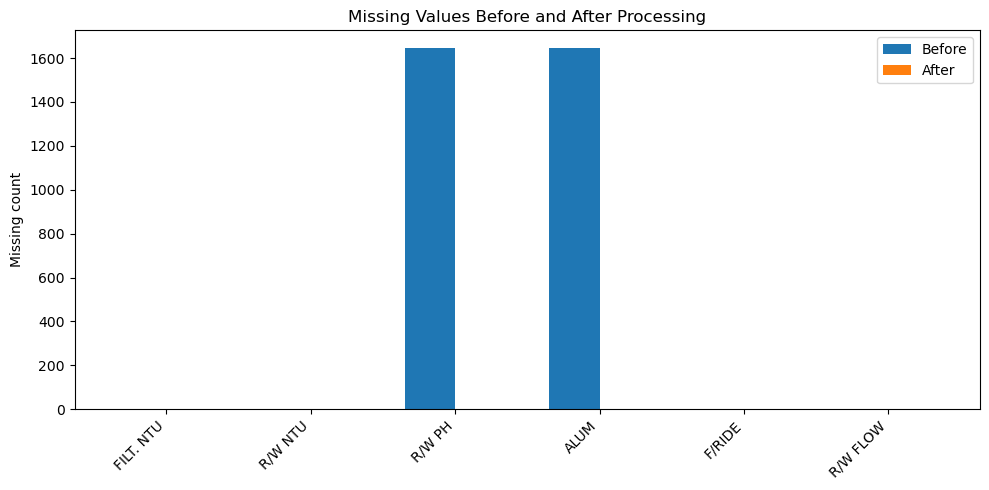

缺失值图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/figures/problem2_missing_before_after.png


In [13]:
missing_plot_df = missing_audit.copy()

x = np.arange(len(missing_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, missing_plot_df["missing_count_before"], width, label="Before")
plt.bar(x + width / 2, missing_plot_df["missing_count_after"], width, label="After")
plt.xticks(x, missing_plot_df["column"], rotation=45, ha="right")
plt.ylabel("Missing count")
plt.title("Missing Values Before and After Processing")
plt.legend()
plt.tight_layout()

missing_fig_path = FIG_DIR / "problem2_missing_before_after.png"
plt.savefig(missing_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("缺失值图已保存：", missing_fig_path)


## 14. 可视化 2：原始差分与截断差分分布

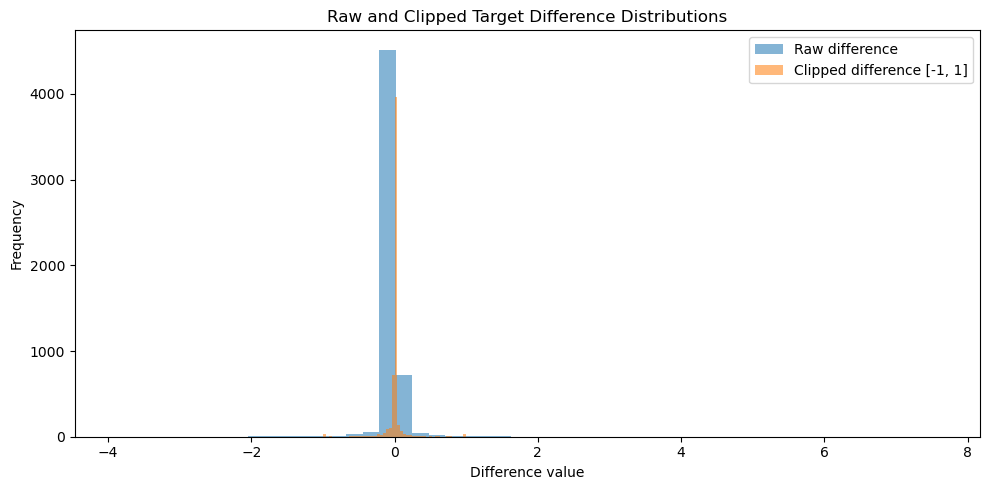

In [14]:
raw_target_diff = clip_data[target_diff_col].dropna()
clip_target_diff = clip_data[target_clip_col].dropna()

plt.figure(figsize=(10, 5))
plt.hist(raw_target_diff, bins=50, alpha=0.55, label="Raw difference")
plt.hist(clip_target_diff, bins=50, alpha=0.55, label="Clipped difference [-1, 1]")
plt.xlabel("Difference value")
plt.ylabel("Frequency")
plt.title("Raw and Clipped Target Difference Distributions")
plt.legend()
plt.tight_layout()

diff_dist_fig_path = FIG_DIR / "problem2_diff_distribution.png"
plt.savefig(diff_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 15. 可视化 3：模型性能对比

输出：

```text
figures/problem2_diff_level_rmse_comparison.png
figures/problem2_diff_level_r2_comparison.png
figures/problem2_model_direction_accuracy_comparison.png
```


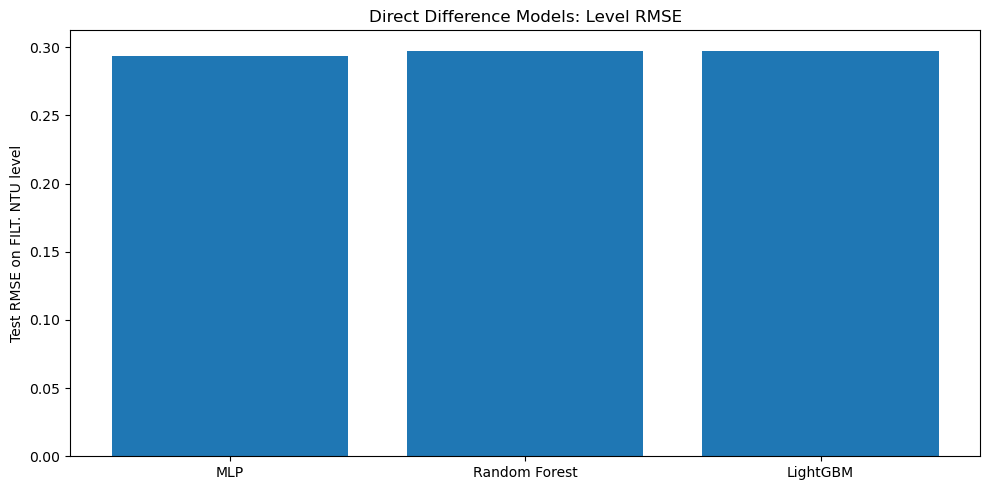

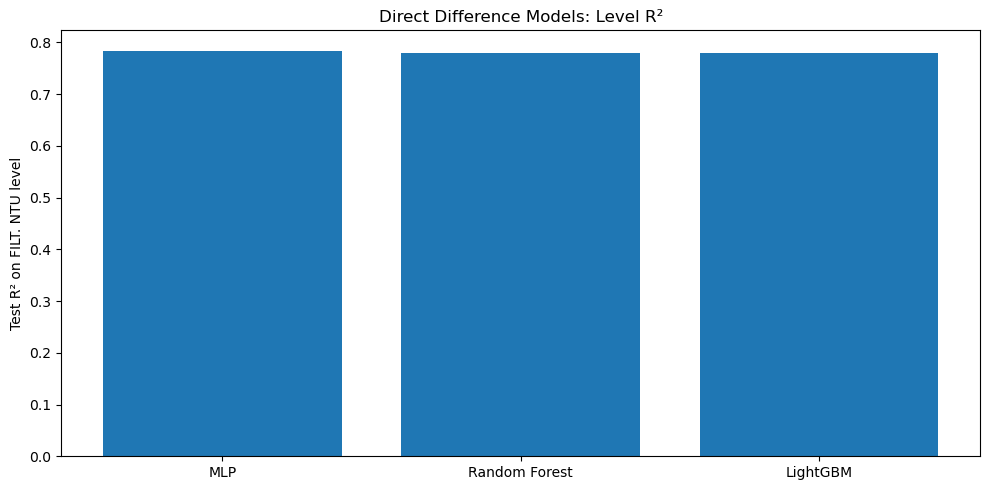

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_level_RMSE"])
plt.ylabel("Test RMSE on FILT. NTU level")
plt.title("Direct Difference Models: Level RMSE")
plt.tight_layout()
rmse_fig_path = FIG_DIR / "problem2_diff_level_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_level_R2"])
plt.ylabel("Test R² on FILT. NTU level")
plt.title("Direct Difference Models: Level R²")
plt.tight_layout()
r2_fig_path = FIG_DIR / "problem2_diff_level_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 16. 可视化 4：最佳模型实际值 vs 预测值

根据测试集 RMSE 最小选择最佳模型。


按原始水平 R² 选择的最佳模型： MLP


,model,n_features,train_samples,test_samples,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy
0,MLP,6,4367,1092,0.057622,0.241631,0.816198,0.060322,0.293789,0.784068,0.046767,0.129036,0.180998,0.049617,0.137902,-0.055118,0.255495


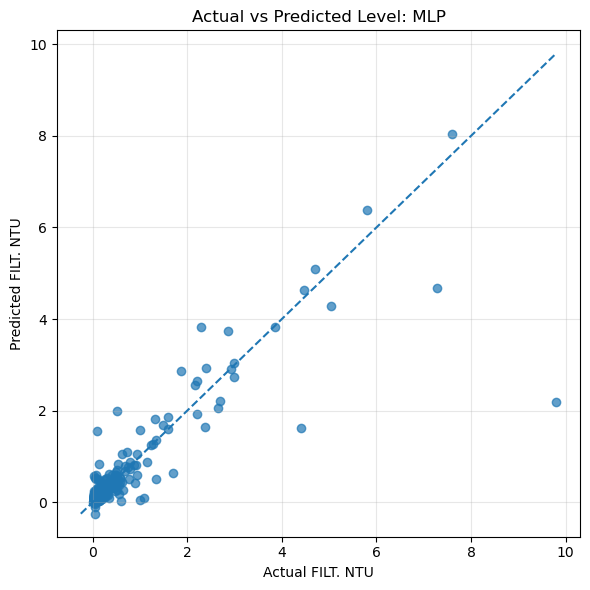

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_pred_df = predictions_df[predictions_df["model"] == best_model_name].copy()

print("按原始水平 R² 选择的最佳模型：", best_model_name)
display(results_df.iloc[[0]])

axis_min = min(best_pred_df[TARGET_COL].min(), best_pred_df["predicted_FILT_NTU"].min())
axis_max = max(best_pred_df[TARGET_COL].max(), best_pred_df["predicted_FILT_NTU"].max())

plt.figure(figsize=(6, 6))
plt.scatter(best_pred_df[TARGET_COL], best_pred_df["predicted_FILT_NTU"], alpha=0.7)
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.xlabel("Actual FILT. NTU")
plt.ylabel("Predicted FILT. NTU")
plt.title(f"Actual vs Predicted Level: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()

scatter_fig_path = FIG_DIR / "problem2_diff_best_model_actual_vs_predicted.png"
plt.savefig(scatter_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 17. 可视化 5：最佳模型测试集时间曲线

虽然数据划分是随机的，但为了观察波动模式，这里按 `DATETIME` 排序后画测试集实际/预测曲线。


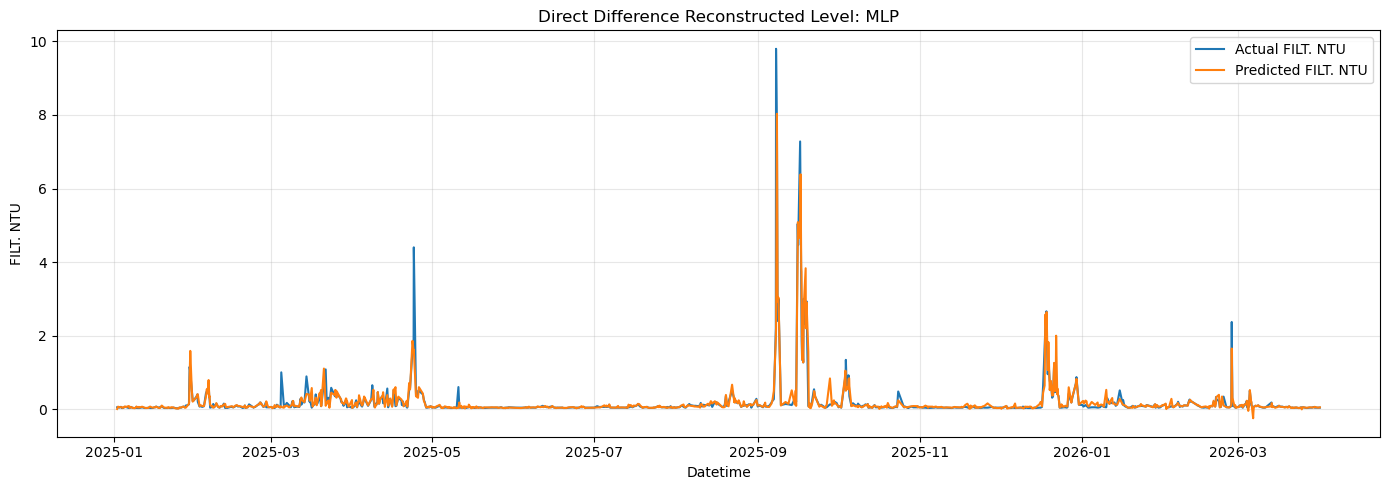

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(best_pred_df["DATETIME"], best_pred_df[TARGET_COL], label="Actual FILT. NTU", linewidth=1.5)
plt.plot(best_pred_df["DATETIME"], best_pred_df["predicted_FILT_NTU"], label="Predicted FILT. NTU", linewidth=1.5)
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.title(f"Direct Difference Reconstructed Level: {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ts_fig_path = FIG_DIR / "problem2_diff_best_model_timeseries.png"
plt.savefig(ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 18. 可视化 6：最佳模型残差分布与残差曲线

输出：

```text
figures/problem2_diff_best_model_residual_distribution.png
figures/problem2_diff_best_model_residual_timeseries.png
```


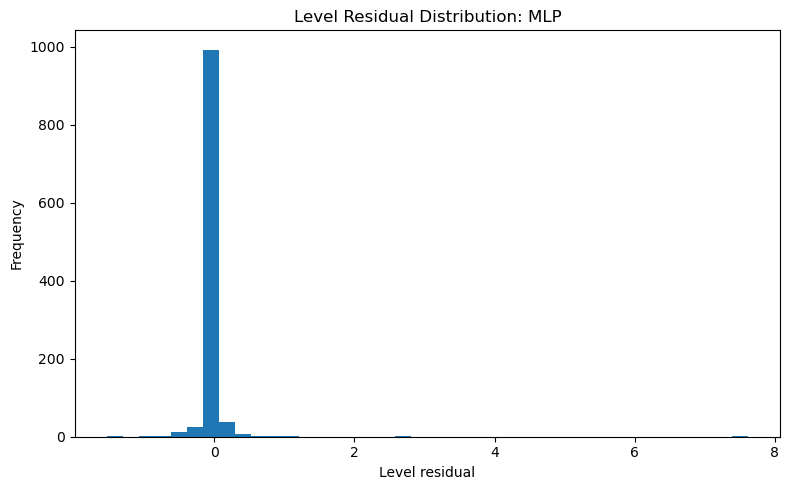

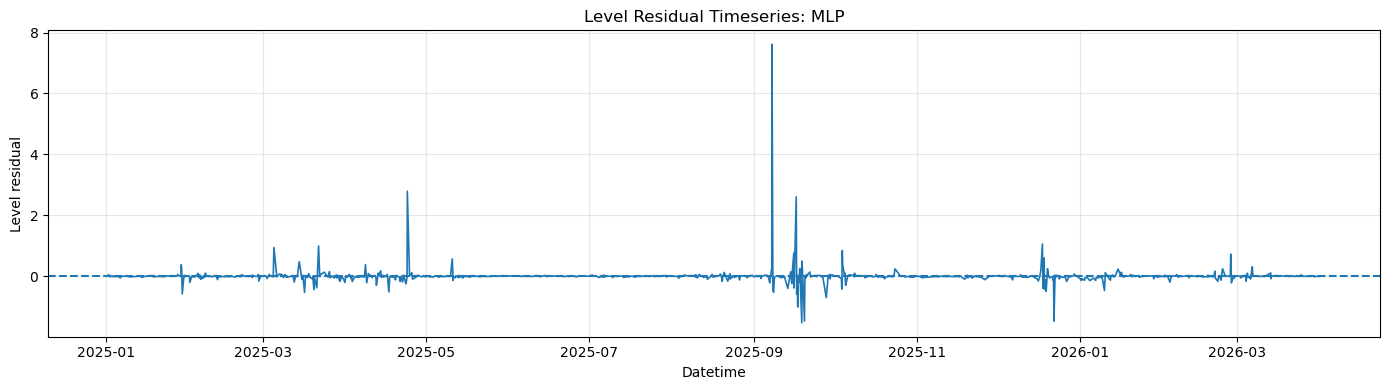

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(best_pred_df["level_residual"], bins=40)
plt.xlabel("Level residual")
plt.ylabel("Frequency")
plt.title(f"Level Residual Distribution: {best_model_name}")
plt.tight_layout()
resid_dist_fig_path = FIG_DIR / "problem2_diff_best_model_residual_distribution.png"
plt.savefig(resid_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(best_pred_df["DATETIME"], best_pred_df["level_residual"], linewidth=1.2)
plt.axhline(0, linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Level residual")
plt.title(f"Level Residual Timeseries: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
resid_ts_fig_path = FIG_DIR / "problem2_diff_best_model_residual_timeseries.png"
plt.savefig(resid_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 19. 可视化 7：特征重要性

如果有树模型特征重要性，则绘制每个模型 Top 15 特征。


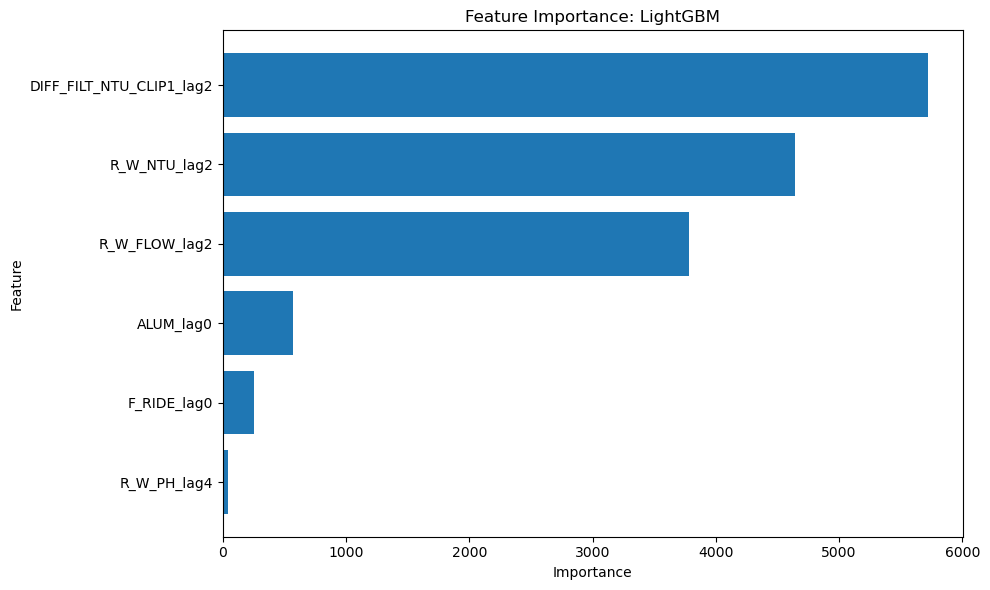

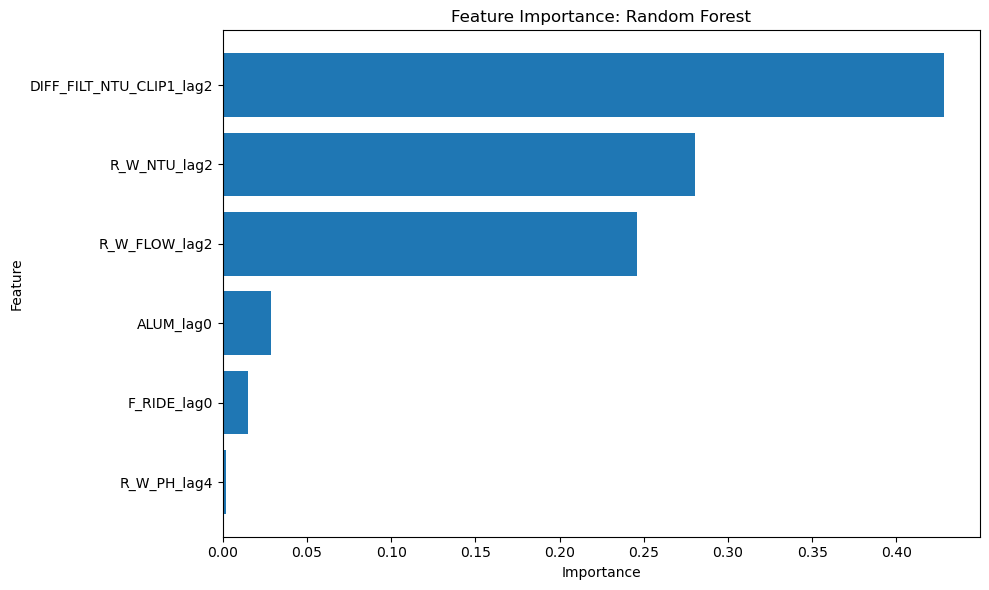

In [19]:
importance_fig_paths = []

for model_name, temp in importance_df.groupby("model"):
    temp = temp.sort_values("importance", ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(temp["feature"][::-1], temp["importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance: {model_name}")
    plt.tight_layout()

    fig_path = FIG_DIR / (
        f"problem2_diff_feature_importance_{model_name}.png"
        .replace(" ", "_")
        .replace("/", "_")
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    importance_fig_paths.append(fig_path)

## 20. 输出汇总工作簿和最终摘要

In [20]:
summary_workbook_path = OUTPUT_DIR / "problem2_diff_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    missing_audit.to_excel(writer, sheet_name="missing_audit", index=False)
    clip_audit_df.to_excel(writer, sheet_name="target_transform", index=False)
    feature_summary_df.to_excel(writer, sheet_name="feature_summary", index=False)
    results_df.to_excel(writer, sheet_name="model_results", index=False)
    predictions_df.to_excel(writer, sheet_name="test_predictions", index=False)
    importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

final_summary = pd.DataFrame([
    {"item": "model_family", "value": "Direct difference regression"},
    {"item": "target", "value": "FILT. NTU first difference clipped to [-1, 1]"},
    {"item": "hurdle_logic", "value": "removed"},
    {"item": "models", "value": "LightGBM, Random Forest, MLP"},
    {
        "item": "level_reconstruction",
        "value": "previous actual FILT. NTU plus predicted difference",
    },
    {
        "item": "model_ranking_rule",
        "value": "highest test R2 on reconstructed FILT. NTU level",
    },
    {"item": "best_model", "value": results_df.iloc[0]["model"]},
    {"item": "best_test_level_MAE", "value": results_df.iloc[0]["test_level_MAE"]},
    {"item": "best_test_level_RMSE", "value": results_df.iloc[0]["test_level_RMSE"]},
    {"item": "best_test_level_R2", "value": results_df.iloc[0]["test_level_R2"]},
    {"item": "best_test_diff_R2", "value": results_df.iloc[0]["test_diff_R2"]},
])

final_summary_path = OUTPUT_DIR / "problem2_diff_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)
display(final_summary)

,item,value
0,model_family,Direct difference regression
1,target,"FILT. NTU first difference clipped to [-1, 1]"
2,hurdle_logic,removed
3,models,"LightGBM, Random Forest, MLP"
4,level_reconstruction,previous actual FILT. NTU plus predicted diffe...
5,model_ranking_rule,highest test R2 on reconstructed FILT. NTU level
6,best_model,MLP
7,best_test_level_MAE,0.060322
8,best_test_level_RMSE,0.293789
9,best_test_level_R2,0.784068


## 21. 论文中可以使用的说明

```text
本文对 FILT. NTU 进行一阶差分并截断至 [-1,1]，不再设置零值阈值或 Hurdle 分类阶段。LightGBM、随机森林和多层感知机使用全部训练样本直接拟合带正负号的差分。测试时，将前一时刻真实 FILT. NTU 与模型预测差分相加，重建当前时刻 FILT. NTU，并在原始水平尺度计算 MAE、RMSE 与 R²。
```

In [21]:
print("=" * 80)
print("问题二：差分直接回归流程已完成。")
print("=" * 80)

print("模型结果：", results_path)
print("测试集预测：", predictions_path)
print("特征重要性：", importance_path)
print("汇总工作簿：", summary_workbook_path)
print("最终摘要：", final_summary_path)
print("模型目录：", MODEL_DIR)

display(results_df)

问题二：差分直接回归流程已完成。
模型结果： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_model_results.xlsx
测试集预测： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_test_predictions.xlsx
特征重要性： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_feature_importance.xlsx
汇总工作簿： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_summary.xlsx
最终摘要： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/problem2_diff_final_summary.xlsx
模型目录： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_direct_bestlag_random80/models


,model,n_features,train_samples,test_samples,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy
0,MLP,6,4367,1092,0.057622,0.241631,0.816198,0.060322,0.293789,0.784068,0.046767,0.129036,0.180998,0.049617,0.137902,-0.055118,0.255495
1,Random Forest,6,4367,1092,0.043268,0.216267,0.852760,0.058325,0.297514,0.778558,0.032414,0.095078,0.555342,0.047620,0.136165,-0.028706,0.248168
2,LightGBM,6,4367,1092,0.050131,0.218023,0.850359,0.064085,0.297528,0.778536,0.039277,0.099762,0.510457,0.053380,0.139148,-0.074281,0.267399
